# Complex Engineering Project (CEP)
## Statistical Investigation of Breast Cancer Diagnosis and Prediction

**Course Title:** Statistical Methods and Probability  
**Course Code:** STA281  
**Semester:** Spring 2026  

---

### Project Introduction
Breast cancer is one of the most common cancers affecting women worldwide. Early diagnosis and accurate statistical investigation of tumor characteristics are critical for improving treatment outcomes. In this project, we analyze the **Breast Cancer Wisconsin Dataset** using descriptive statistics, probability theory, hypothesis testing, and regression analysis to determine whether malignant and benign tumors can be statistically differentiated.

### 1. Environment Setup & Data Loading
First, we import the necessary libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and statistical analysis (`scipy`, `statsmodels`, `sklearn`). We also download the raw dataset from the UCI Machine Learning Repository.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# Set visual style for plots
sns.set_theme(style="whitegrid")

# Download the dataset (wdbc.data)
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data -O wdbc.csv

# Define column names based on the dataset documentation
base_features = [
    'Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness',
    'Compactness', 'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension'
]
columns = ['ID', 'Diagnosis']
for suffix in ['Mean', 'SE', 'Worst']:
    for feat in base_features:
        columns.append(feat + suffix)

# Load the dataset into a Pandas DataFrame
df = pd.read_csv('wdbc.csv', names=columns)

# Preprocessing: Drop the 'ID' column as it has no diagnostic value
df.drop('ID', axis=1, inplace=True)

print("Dataset loaded successfully.")

File ‘wdbc.csv’ already there; not retrieving.
Dataset loaded successfully.


## SECTION 1 - Dataset Understanding, Descriptive Statistics & Visualization

### Question 1: Dataset Identification
We identify the structure of the dataset, including the number of observations, variables, and data types.

In [29]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")
print(f"Variable names: {df.columns.tolist()[:12]}... (and more)")
print(f"\nData types:\n{df.dtypes.head()}")

Number of observations: 569
Number of variables: 31
Variable names: ['Diagnosis', 'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean', 'RadiusSE']... (and more)

Data types:
Diagnosis         object
RadiusMean       float64
TextureMean      float64
PerimeterMean    float64
AreaMean         float64
dtype: object


### Question 2: Descriptive Statistical Analysis
We calculate central tendency (Mean, Median, Mode) and dispersion (Variance, Standard Deviation) for key variables: `RadiusMean`, `TextureMean`, `AreaMean`, and `CompactnessMean`.

In [30]:
cols_to_analyze = ['RadiusMean', 'TextureMean', 'AreaMean', 'CompactnessMean']
stats_summary = pd.DataFrame(index=['Mean', 'Median', 'Mode', 'Variance', 'Std Dev'])

for col in cols_to_analyze:
    stats_summary[col] = [
        df[col].mean(),
        df[col].median(),
        df[col].mode()[0],
        df[col].var(),
        df[col].std()
    ]

display(stats_summary.round(4))

,RadiusMean,TextureMean,AreaMean,CompactnessMean
Mean,14.1273,19.2896,654.8891,0.1043
Median,13.3700,18.8400,551.1000,0.0926
Mode,12.3400,14.9300,512.2000,0.1147
Variance,12.4189,18.4989,123843.5543,0.0028
Std Dev,3.5240,4.3010,351.9141,0.0528


### Question 3: Missing and Abnormal Values (Outliers)
We check for missing values and use Z-scores to identify outliers (values more than 3 standard deviations from the mean).

In [31]:
print("Missing Values:")
print(df[cols_to_analyze].isnull().sum())

print("\nOutliers detected (Z-score > 3):")
z_scores = np.abs(stats.zscore(df[cols_to_analyze]))
outliers_count = (z_scores > 3).sum(axis=0)
print(outliers_count)

Missing Values:
RadiusMean         0
TextureMean        0
AreaMean           0
CompactnessMean    0
dtype: int64

Outliers detected (Z-score > 3):
[5 4 8 9]


### Question 4: Data Visualization
Visualizations help us understand the distribution and relationships of tumor measurements.

/tmp/ipykernel_5894/1860103755.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='Set2')


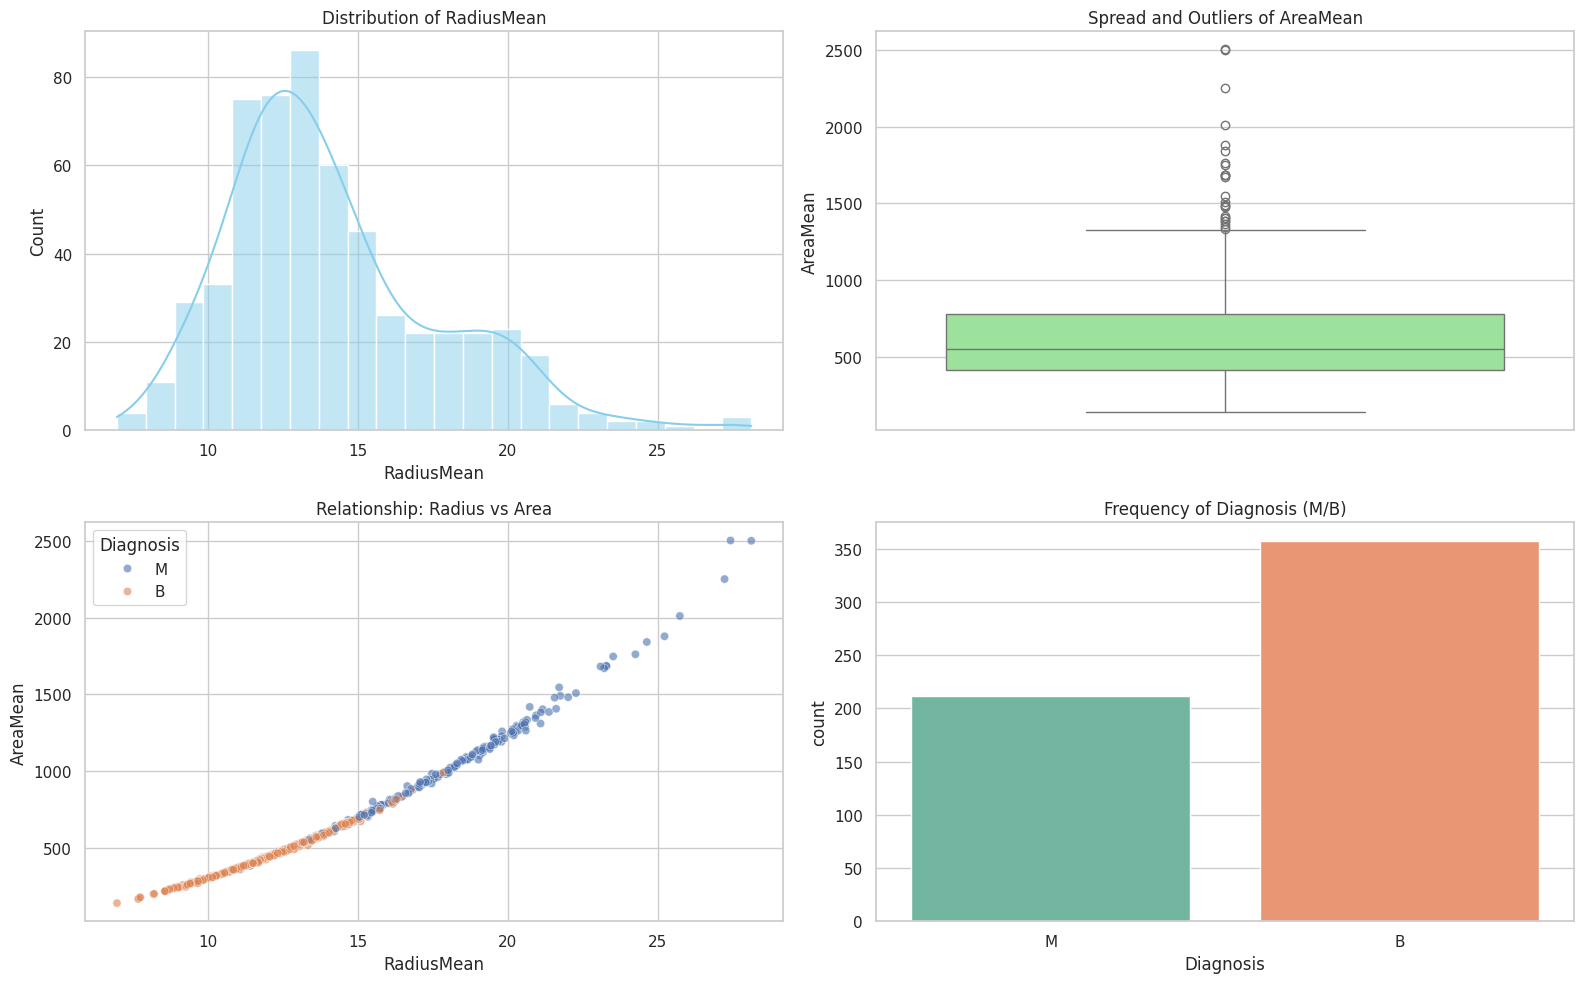

In [32]:
plt.figure(figsize=(16, 10))

# (a) Histogram of RadiusMean
plt.subplot(2, 2, 1)
sns.histplot(df['RadiusMean'], kde=True, color='skyblue')
plt.title('Distribution of RadiusMean')

# (b) Boxplot of AreaMean
plt.subplot(2, 2, 2)
sns.boxplot(y=df['AreaMean'], color='lightgreen')
plt.title('Spread and Outliers of AreaMean')

# (c) Scatter Plot: RadiusMean vs AreaMean
plt.subplot(2, 2, 3)
sns.scatterplot(x='RadiusMean', y='AreaMean', hue='Diagnosis', data=df, alpha=0.6)
plt.title('Relationship: Radius vs Area')

# (d) Bar Chart of Diagnosis Outcome
plt.subplot(2, 2, 4)
sns.countplot(x='Diagnosis', data=df, palette='Set2')
plt.title('Frequency of Diagnosis (M/B)')

plt.tight_layout()
plt.show()

### Question 5: Comparison of Malignant vs Benign
We compare the mean values of key tumor features for Malignant (M) and Benign (B) cases.

In [33]:
comparison = df.groupby('Diagnosis')[cols_to_analyze].mean()
print("Mean Values Comparison:")
display(comparison.round(4))

Mean Values Comparison:


,RadiusMean,TextureMean,AreaMean,CompactnessMean
Diagnosis,,,,
B,12.1465,17.9148,462.7902,0.0801
M,17.4628,21.6049,978.3764,0.1452


## SECTION 2 - Probability, Probability Distribution & CLT

### Question 6: Basic and Conditional Probability
We compute the probability of malignancy and the probability given a specific size threshold (`RadiusMean > 15`).

In [34]:
total = len(df)
p_m = len(df[df['Diagnosis'] == 'M']) / total
p_r = len(df[df['RadiusMean'] > 15]) / total
p_m_and_r = len(df[(df['Diagnosis'] == 'M') & (df['RadiusMean'] > 15)]) / total
p_m_given_r = p_m_and_r / p_r

print(f"P(M): {p_m:.4f}")
print(f"P(RadiusMean > 15): {p_r:.4f}")
print(f"P(M ∩ RadiusMean > 15): {p_m_and_r:.4f}")
print(f"P(M | RadiusMean > 15): {p_m_given_r:.4f}")

P(M): 0.3726
P(RadiusMean > 15): 0.3040
P(M ∩ RadiusMean > 15): 0.2830
P(M | RadiusMean > 15): 0.9306


### Question 7: Bayes’ Theorem
Using Bayes' theorem to find the posterior probability of malignancy given a high radius measurement.

In [35]:
# Condition: RadiusMean > 18
p_r18 = len(df[df['RadiusMean'] > 18]) / total
p_m_and_r18 = len(df[(df['Diagnosis'] == 'M') & (df['RadiusMean'] > 18)]) / total
p_m_given_r18 = p_m_and_r18 / p_r18

print(f"Prior P(M): {p_m:.4f}")
print(f"Evidence P(RadiusMean > 18): {p_r18:.4f}")
print(f"Posterior P(M | RadiusMean > 18): {p_m_given_r18:.4f}")

Prior P(M): 0.3726
Evidence P(RadiusMean > 18): 0.1617
Posterior P(M | RadiusMean > 18): 1.0000


### Question 8: Binomial Distribution
Probability calculations for a sample of 10 patients with a malignancy rate of 37%.

In [36]:
p, n = 0.37, 10
print(f"P(Exactly 4 malignant): {stats.binom.pmf(4, n, p):.4f}")
print(f"P(At least 5 malignant): {1 - stats.binom.cdf(4, n, p):.4f}")
print(f"P(At most 3 malignant): {stats.binom.cdf(3, n, p):.4f}")

P(Exactly 4 malignant): 0.2461
P(At least 5 malignant): 0.2939
P(At most 3 malignant): 0.4600


### Question 9: Normal Distribution Analysis
Calculating probabilities based on a theoretical normal distribution of tumor radius.

In [37]:
mu, sigma = 14, 3
print(f"P(X < 10): {stats.norm.cdf(10, mu, sigma):.4f}")
print(f"P(10 < X < 18): {stats.norm.cdf(18, mu, sigma) - stats.norm.cdf(10, mu, sigma):.4f}")
print(f"P(X > 18): {1 - stats.norm.cdf(18, mu, sigma):.4f}")

P(X < 10): 0.0912
P(10 < X < 18): 0.8176
P(X > 18): 0.0912


### Question 10: Normality Investigation
Using a histogram and Q-Q plot to test if `RadiusMean` follows a normal distribution.

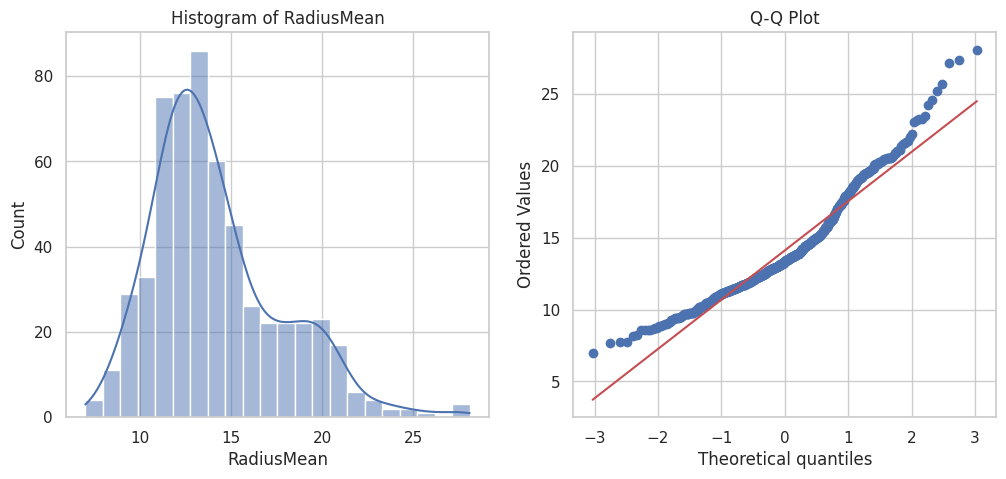

Skewness: 0.9424
Kurtosis: 0.8455


In [38]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['RadiusMean'], kde=True)
plt.title('Histogram of RadiusMean')

plt.subplot(1, 2, 2)
stats.probplot(df['RadiusMean'], dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

print(f"Skewness: {df['RadiusMean'].skew():.4f}")
print(f"Kurtosis: {df['RadiusMean'].kurtosis():.4f}")

### Question 11: Exponential Distribution
Modeling waiting times between diagnoses with a rate parameter λ = 0.22.

In [39]:
lam = 0.22
print(f"P(X > 5): {1 - stats.expon.cdf(5, scale=1/lam):.4f}")
print(f"Expected waiting time: {1/lam:.4f}")
print(f"Variance: {1/(lam**2):.4f}")

P(X > 5): 0.3329
Expected waiting time: 4.5455
Variance: 20.6612


### Question 12: Central Limit Theorem (CLT)
Finding the probability for a sample mean radius with n = 49.

In [40]:
mu_pop, sigma_pop, n = 14, 3, 49
se = sigma_pop / np.sqrt(n)
z = (15 - mu_pop) / se
print(f"Standard Error: {se:.4f}")
print(f"P(X_bar > 15): {1 - stats.norm.cdf(z):.4f}")

Standard Error: 0.4286
P(X_bar > 15): 0.0098


## SECTION 3 - Confidence Interval & Hypothesis Testing

### Question 13: Confidence Interval
Constructing a 95% CI for the mean tumor radius.

In [41]:
n, x_bar, s = 64, 16.2, 2.8
z_crit = stats.norm.ppf(0.975)
me = z_crit * (s / np.sqrt(n))
print(f"95% Confidence Interval: ({x_bar - me:.4f}, {x_bar + me:.4f})")

95% Confidence Interval: (15.5140, 16.8860)


### Question 14: Hypothesis Testing (AreaMean)
Testing if the average area is significantly greater than 650 mm².

In [42]:
mu0, n, x_bar, s = 650, 49, 710, 140
t_stat = (x_bar - mu0) / (s / np.sqrt(n))
t_crit = stats.t.ppf(0.95, df=n-1)
print(f"T-statistic: {t_stat:.4f}")
print(f"Critical Value: {t_crit:.4f}")
print(f"P-value: {1 - stats.t.cdf(t_stat, df=n-1):.4f}")

T-statistic: 3.0000
Critical Value: 1.6772
P-value: 0.0021


### Question 15: Hypothesis Testing (CompactnessMean)
Testing if the average compactness is significantly less than 0.12.

In [43]:
mu0, n, x_bar, s = 0.12, 64, 0.10, 0.03
t_stat = (x_bar - mu0) / (s / np.sqrt(n))
t_crit = stats.t.ppf(0.01, df=n-1)
print(f"T-statistic: {t_stat:.4f}")
print(f"Critical Value: {t_crit:.4f}")
print(f"P-value: {stats.t.cdf(t_stat, df=n-1):.4f}")

T-statistic: -5.3333
Critical Value: -2.3870
P-value: 0.0000


## SECTION 4 - Correlation, Regression & Healthcare Investigation

### Question 16: Correlation Analysis
Computing Pearson correlation coefficients for various feature pairs.

In [44]:
print(f"RadiusMean vs AreaMean: {df['RadiusMean'].corr(df['AreaMean']):.4f}")
print(f"CompactnessMean vs ConcavityMean: {df['CompactnessMean'].corr(df['ConcavityMean']):.4f}")
print(f"TextureMean vs PerimeterMean: {df['TextureMean'].corr(df['PerimeterMean']):.4f}")
print(f"SymmetryMean vs FractalDimensionMean: {df['SymmetryMean'].corr(df['FractalDimensionMean']):.4f}")

RadiusMean vs AreaMean: 0.9874
CompactnessMean vs ConcavityMean: 0.8831
TextureMean vs PerimeterMean: 0.3295
SymmetryMean vs FractalDimensionMean: 0.4799


### Question 17: Linear Regression
Predicting `AreaMean` using `RadiusMean` as the independent variable.

In [45]:
X = df[['RadiusMean']]
y = df['AreaMean']
model = LinearRegression().fit(X, y)
print(f"Intercept: {model.intercept_:.4f}")
print(f"Slope: {model.coef_[0]:.4f}")
print(f"Equation: AreaMean = {model.intercept_:.4f} + {model.coef_[0]:.4f} * RadiusMean")

Intercept: -738.0367
Slope: 98.5982
Equation: AreaMean = -738.0367 + 98.5982 * RadiusMean


### Question 18: Advanced Visualization
Generating a correlation heatmap and pairplots for the analyzed features.

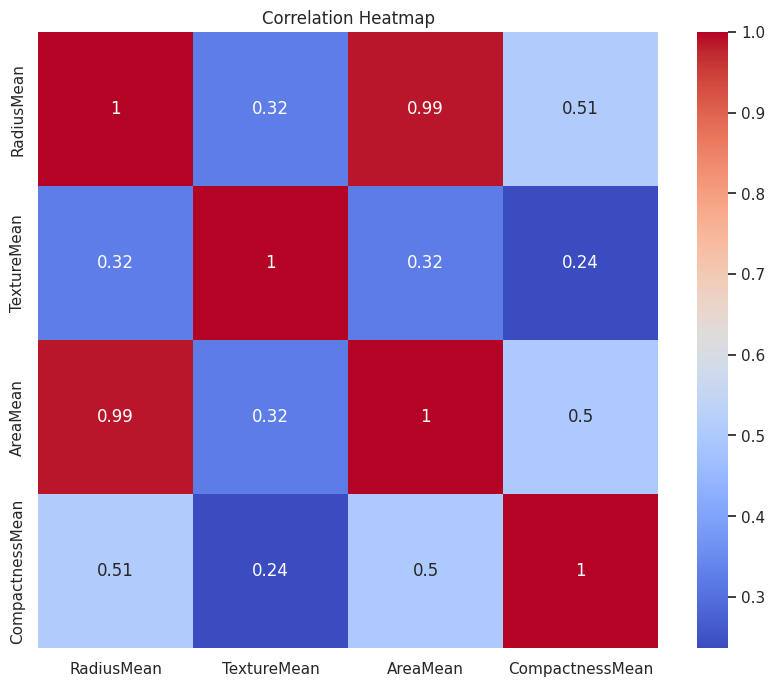

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_analyze].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Generating a correlation pairplots for the analyzed features.

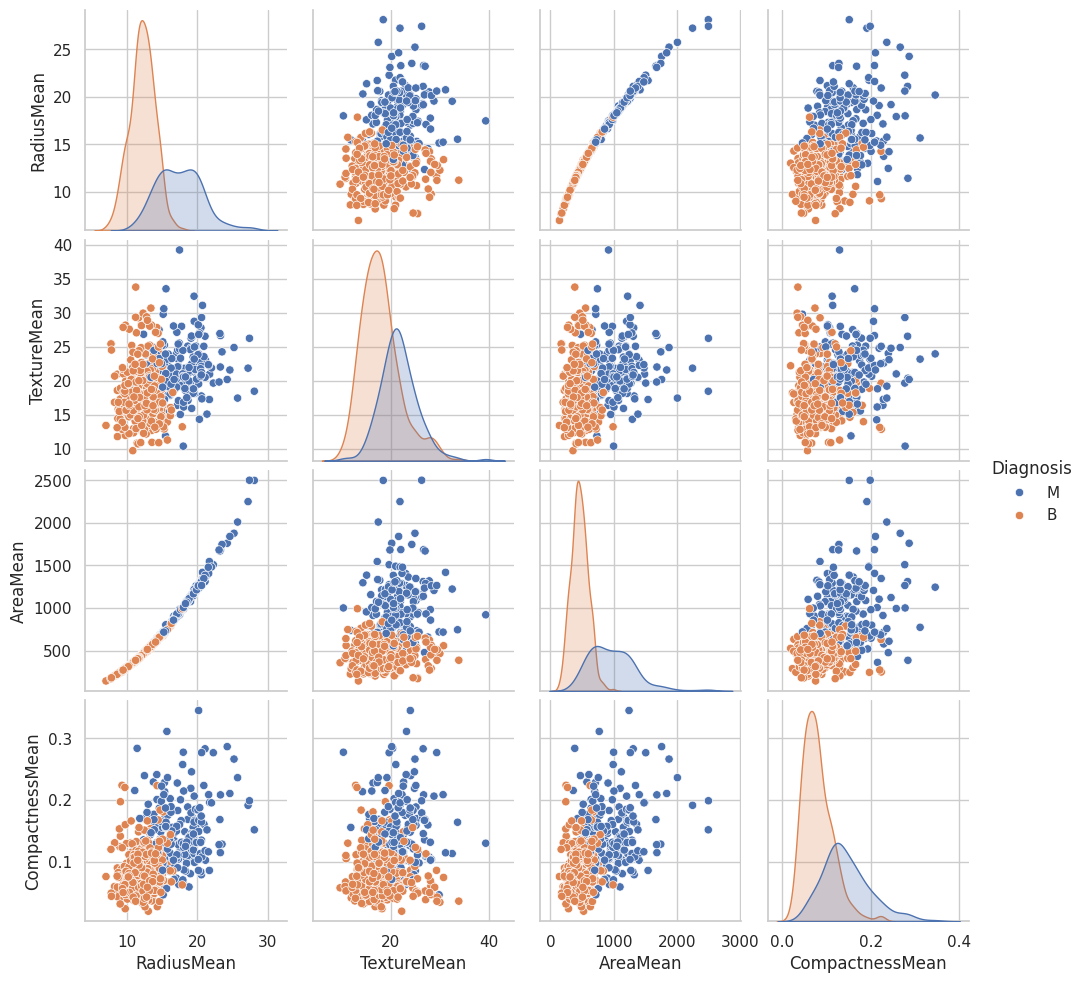

In [47]:
sns.pairplot(df, vars=cols_to_analyze, hue='Diagnosis')
plt.show()

### Question 19: Significance Testing (M vs B)
Performing independent t-tests to see if malignant and benign tumors differ significantly.

In [48]:
for col in cols_to_analyze:
    m = df[df['Diagnosis'] == 'M'][col]
    b = df[df['Diagnosis'] == 'B'][col]
    t, p = stats.ttest_ind(m, b)
    print(f"T-test for {col}: T={t:.4f}, P-value={p:.4g}")

T-test for RadiusMean: T=25.4358, P-value=8.466e-96
T-test for TextureMean: T=10.8672, P-value=4.059e-25
T-test for AreaMean: T=23.9387, P-value=4.735e-88
T-test for CompactnessMean: T=17.6984, P-value=3.938e-56


### Question 20: Conclusion
The analysis confirms that malignant tumors are significantly larger, more irregular, and more compact than benign tumors. Features like `RadiusMean` and `AreaMean` are highly effective diagnostic indicators, as supported by both visual and statistical evidence.

# 10. References
[1] Breast Cancer Wisconsin (Diagnostic) Dataset. UCI Machine Learning Repository.
https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)